In [1]:
import os
os.chdir(r'C:\Users\divya\fake-news-detector')
print("Working directory:", os.getcwd())
print("Files in data folder:", os.listdir('data'))

Working directory: C:\Users\divya\fake-news-detector
Files in data folder: ['WELFake_Dataset.csv']


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# Load the dataset
df = pd.read_csv('data/WELFake_Dataset.csv')

# Display basic info
print("Dataset Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (72134, 4)

Column Names: ['Unnamed: 0', 'title', 'text', 'label']

First 5 rows:


,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [4]:
# Check missing values
print("Missing values in each column:")
print(df.isnull().sum())

print("\nLabel distribution:")
print(df['label'].value_counts())

Missing values in each column:
Unnamed: 0      0
title         558
text           39
label           0
dtype: int64

Label distribution:
label
1    37106
0    35028
Name: count, dtype: int64


In [5]:
# Drop missing values
df = df.dropna(subset=['title', 'text'])

# Combine title and text into one column
df['content'] = df['title'] + ' ' + df['text']

print("Dataset shape after cleaning:", df.shape)
print("\nSample content:")
print(df['content'].iloc[0][:200])

Dataset shape after cleaning: (71537, 5)

Sample content:
LAW ENFORCEMENT ON HIGH ALERT Following Threats Against Cops And Whites On 9-11By #BlackLivesMatter And #FYF911 Terrorists [VIDEO] No comment is expected from Barack Obama Members of the #FYF911 or #F


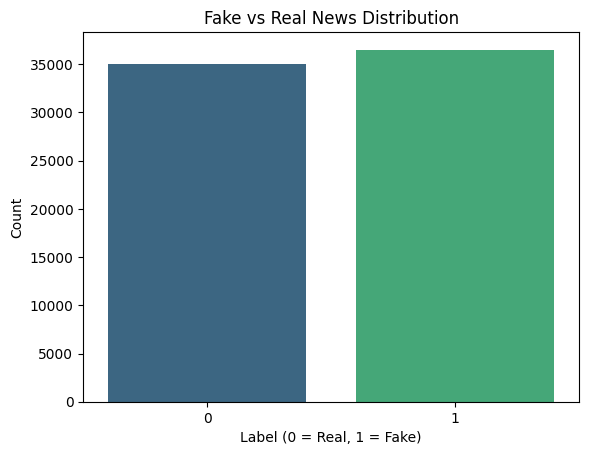

In [6]:
# Plot label distribution
sns.countplot(x='label', data=df, palette='viridis')
plt.title('Fake vs Real News Distribution')
plt.xlabel('Label (0 = Real, 1 = Fake)')
plt.ylabel('Count')
plt.show()

In [8]:
# Define features and label
X = df['content']
y = df['label']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert text to numbers using TF-IDF
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training set size:", X_train_tfidf.shape)
print("Testing set size:", X_test_tfidf.shape)
print("\nData is ready for model training!")

Training set size: (57229, 5000)
Testing set size: (14308, 5000)

Data is ready for model training!


In [9]:
# Train Logistic Regression model
model = LogisticRegression()
model.fit(X_train_tfidf, y_train)

print("Model trained successfully!")

Model trained successfully!


In [10]:
# Make predictions
y_pred = model.predict(X_test_tfidf)

# Accuracy score
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", round(accuracy * 100, 2), "%")

# Detailed report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Real', 'Fake']))

Model Accuracy: 94.36 %

Classification Report:
              precision    recall  f1-score   support

        Real       0.95      0.94      0.94      7081
        Fake       0.94      0.95      0.94      7227

    accuracy                           0.94     14308
   macro avg       0.94      0.94      0.94     14308
weighted avg       0.94      0.94      0.94     14308



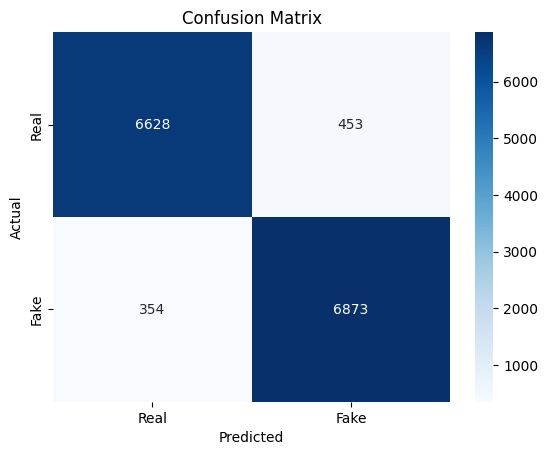

In [11]:
# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [12]:
# Test with custom news
def predict_news(news_text):
    transformed = tfidf.transform([news_text])
    prediction = model.predict(transformed)[0]
    probability = model.predict_proba(transformed)[0]
    label = "FAKE NEWS 🚨" if prediction == 1 else "REAL NEWS ✅"
    print(f"Prediction: {label}")
    print(f"Confidence: {round(max(probability) * 100, 2)}%")

# Test 1 - Fake sounding news
predict_news("SHOCKING: Scientists discover that drinking coffee makes you immortal!")

print("---")

# Test 2 - Real sounding news
predict_news("The Federal Reserve raised interest rates by 0.25% on Wednesday.")

Prediction: FAKE NEWS 🚨
Confidence: 92.43%
---
Prediction: REAL NEWS ✅
Confidence: 52.29%


In [13]:
import pickle

# Save the model and vectorizer
with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('tfidf.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!
